# Obnoxious _p_-Median Problem

## Problem definition

In the broader topic of facility location disparsing, obnoxious facilities were not taken into account when modelling such problems. Obnoxious facilities includes nuclear power plants, waste dumpsites and other structures that negatively impact clients, the environment and other facilities. The problem discussed in this notebook handles such cases, trying to maximize the distance between obnoxious plants and other facilities.

## The unified model
Based on the method of Ogryczak and Tamir for minimizing the sum of the K largest 
functions, Lei and Church proposed a unified dispersion model where distances are 
measured between facilities. The adaptation to the OpMP setting requires a key 
conceptual shift: distances are now measured from **clients to facilities** rather 
than between facilities. This change is reflected both in the index set (I instead 
of J for the outer variables) and in the coefficient of $s_i$, which becomes L instead 
of L+1, since client i is not itself a facility and contributes no zero self-distance.

### Parameters and Variables

**Sets:**
- $I = \{1, \dots, n\}$: set of clients
- $J = \{1, \dots, m\}$: set of potential facility sites

**Parameters:**
- $d(i, j)$: distance between client $i \in I$ and facility $j \in J$
- $p$: number of facilities to open
- $K$: number of clients considered in the objective (set to $n$ for the OpMP)
- $L$: number of closest facilities considered per client (set to $1$ for the OpMP)
- $M$: a sufficiently large constant

**Decision variables:**
- $y_j \in \{0,1\}$: equals $1$ if facility $j$ is opened, $0$ otherwise

### Model Formulation

$$\max \; Kt - \sum_{i \in I} u_i \tag{12}$$

**Subject to:**

$$t - u_i \leq q_i \qquad \forall i \in I \tag{13}$$

$$q_i = Ls_i - \sum_{j \in J} z(i,j) \qquad \forall i \in I \tag{14}$$

$$s_i - z(i,j) \leq d(i,j) + M(1 - y_j) \qquad \forall i \in I, \forall j \in J \tag{15}$$

$$\sum_{j \in J} y_j = p \tag{3}$$

$$u_i, z(i,j) \geq 0, \quad y_j \in \{0,1\} \qquad \forall i \in I, \forall j \in J$$

#### Auxiliary Variables, Constraints and Objective Intuition

To address the relationship between such variables and provide a better understanding of the model, instead of providing a strictly formal definition of them, I prefer to stick on their natural understanding.

1) **Relationship between $t$, $u_i$ and $q_i$**

    Consider first of all the constraint:

    $$t - u_i \leq q_i \qquad \forall i \in I \tag{13}$$

    - $q_i$: at optimality, it assumes the distance to its nearest open facility (exactly analogous to the compact model variable $D_i$). Non-negative by meaning, even though it isn't explicitly bounded as such in the model.

    - $t \in \mathbb{R}$: a threshold value, automatically optimized by the model (not fixed a priori). It only serves to isolate the $K$ smallest $q_i$'s, following the approach of Ogryczak and Tamir.

    - $u_i \geq 0$: combined with constraint (13), it is forced to $u_i = \max(0, t - q_i)$ at optimality.

    The identity behind this construction is:

    $$\sum_{i=1}^{K} q_i^{(\text{smallest})} = K t - \sum_{i \in I} u_i$$

    (i.e. the sum of the $K$ smallest $q_i$'s can be written as a linear expression in $t$ and $u_i$, for any $t$ between the $K$-th and $(K+1)$-th smallest value) 

    **Observations**:

    1. Note that for other values of $t$, the previous expression is not an identity, we obtain $LHS \ge RHS$
    
    2. Setting $K = n$ makes the right-hand side equal to $\sum_i q_i$, recovering the OpMP objective.

    From **Observation 2.** we can induce an ordering of the smallest distances $q_i$ without relying on a non-linear function and use such construction as our objective function.


2) **Relationship between $L$, $s_i$ and $z(i,j)$**

    Consider the constraints:

    $$q_i = L \, s_i - \sum_{j \in J} z(i,j) \qquad \forall i \in I \tag{14}$$
    $$s_i - z(i,j) \leq d(i,j) + M(1 - y_j) \qquad \forall i \in I, j \in J \tag{15}$$

    - $s_i \geq 0$: pushed by constraint (15) toward the distance to the nearest *open* facility — the big-$M$ term switches the constraint off for any closed facility ($y_j = 0$).

    - $z(i,j) \geq 0$: the excess distance of an open facility $j$ over $s_i$. At optimality it is $0$ for every open facility, since increasing it only lowers $q_i$ through (14), while non-negativity rules out negative values for farther facilities.

    - $L$: how many of the nearest open facilities are folded into $q_i$. 
    Setting $L = 1$ collapses the whole machinery to $q_i = s_i = D_i$, the distance to the single nearest open facility — exactly what the OpMP needs.

3) **Constraint (3)**

    The last thing that we need to cover is the third constraint:

    $$\sum_{j \in J} y_j = p \tag{3}$$

    This is simply saying that the number of opened facilities $\sum_{j \in J} y_j$ must be equal to $p$



### Implementation

In [1]:
import gurobipy as gp
from gurobipy import GRB

#### Mapping to the Gurobi's implementation
To implement the above model, I define the following function:

```python
solve_unified_opmp(n, m, p, d, K=None, L=1, M=None)
```

with **Parameters**:
```python
n: int   # number of clients (|I|)
m: int   # number of potential facility sites (|J|)
p: int   # number of facilities to open
d: list[list[float]] # distance matrix, d[i][j] = distance from client i to facility j
K: int   # clients counted in the objective; defaults to n (full OpMP)
L: int   # closest facilities considered per client; defaults to 1 (full OpMP)
M: float # big-M constant; defaults to max distance in d
```
and **Returns a dictionary** with keys:
```python
"obj": model.ObjVal, # optimal objective value
"open": open_facilities, # list of opened facility indices
"assignment": assignment, # dict mapping each client i to its nearest open facility
"model": model, # the solved Gurobi Model object
```

In [2]:
def solve_unified_opmp(n, m, p, d, K=None, L=1, M=None):

    """
    I decided to preserve the original modular structure of the problem, in which one can redefine K and L.

    Here I want to stick with K = n and L = 1 to implement the intended OpMP model:
    - K = n to maximize the smallest distances from the facilities of all the clients
    - L = 1 to consider the distances of the other facilities from a client, only in relation to the nearest one
    """

    if K is None:
        K = n  # with K=n the model is equivalent to the compact OpMP
        
    if M is None:
        M = max(d[i][j] for i in range(n) for j in range(m))


    I = range(n)  # client index set
    J = range(m)  # facility index set


    model = gp.Model("unified_opmp")


    # Decisional variables

    y = model.addVars(J, vtype=GRB.BINARY, name="y")


    # Auxiliary variables

    t = model.addVar(lb=-GRB.INFINITY, name="t")

    u = model.addVars(I, lb=0.0, name="u")

    s = model.addVars(I, lb=0.0, name="s")
    
    z = model.addVars(I, J, lb=0.0, name="z")

    q = model.addVars(I, lb=0.0, name="q")


    # Objective function

    model.setObjective(
        K * t - gp.quicksum(u[i] for i in I),
        GRB.MAXIMIZE
    )


    # Constraint: t - u[i] <= q[i]  for all i 
    
    model.addConstrs(
        (t - u[i] <= q[i] for i in I),
        name="link_u_q"
    )


    # Constraint: q[i] = L*s[i] - sum_j z[i,j]  for all i 

    model.addConstrs(
        (q[i] == L * s[i] - gp.quicksum(z[i, j] for j in J) for i in I),
        name="def_q"
    )


    # Constraint: s[i] - z[i,j] <= d[i][j] + M*(1-y[j])  

    model.addConstrs(
        (s[i] - z[i, j] <= d[i][j] + M * (1 - y[j]) for i in I for j in J),
        name="bigM"
    )


    # Constraint: sum_j y[j] = p  

    model.addConstr(
        gp.quicksum(y[j] for j in J) == p,
        name="cardinality"
    )


    model.optimize()


    # Solution extraction
    open_facilities = [j for j in J if y[j].X > 0.5]


    # Recover the nearest open facility for each client from the distance matrix
    assignment = {
        i: min(open_facilities, key=lambda j: d[i][j])
        for i in I
    }
    

    return {
        "obj": model.ObjVal,
        "open": open_facilities,
        "assignment": assignment,
        "model": model,
    }

### Plotting: Network structure

It's useful to visualize the client-facility network both before and after optimization. The legend below applies to every plot in this notebook:

| Element | Meaning |
|---|---|
| **Blue square** | Potential facility site $j \in J$ |
| **Orange circle** | Client $i \in I$ |
| **Grey edge** | One of the $k$ nearest facilities to a client (shown *before* optimization to convey the overall structure) |
| **Green square** | Facility selected by the optimization ($y_j = 1$) |
| **Red edge** | Assignment of a client to its nearest *open* facility (shown *after* optimization) |

For instances with 2D coordinates (`euclidean` format) the true positions are used. For instances given only as a distance table (`table` format), node positions are approximated via **Multidimensional Scaling (MDS)** applied to the distance matrix, so relative proximity is still meaningful even though absolute coordinates do not exist in the original data.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
from sklearn.manifold import MDS


def get_positions(inst: dict) -> tuple[dict, dict]:
    """
    Return two position dicts:
      client_pos   : {i: (x, y)}  for i in range(n)
      facility_pos : {j: (x, y)}  for j in range(m)

    If the instance carries 2D coordinates (euclidean format, inst['coords']
    is not None) those are used directly. Otherwise MDS is applied to the
    (n+m) x (n+m) distance block built from d[i][j].
    """
    if inst.get("coords") is not None:
        clients    = inst["coords"]["clients"]
        facilities = inst["coords"]["facilities"]
        client_pos   = {i: clients[i]    for i in range(inst["n"])}
        facility_pos = {j: facilities[j] for j in range(inst["m"])}
        return client_pos, facility_pos

    # table format: approximate with MDS on the distance matrix
    n, m, d = inst["n"], inst["m"], inst["d"]
    N = n + m

    # Build a symmetric (N x N) dissimilarity matrix.
    # d[i][j] gives client i -> facility j distances directly.
    # Client-client and facility-facility distances are estimated via the
    # triangle inequality: dist(a,b) ≈ min_k( d[a][k] + d[b][k] ) / 2.
    D = np.zeros((N, N))
    d_arr = np.array(d)  # shape (n, m)

    # client-facility block
    for i in range(n):
        for j in range(m):
            D[i, n + j] = d_arr[i, j]
            D[n + j, i] = d_arr[i, j]

    # client-client distances
    for i in range(n):
        for i2 in range(i + 1, n):
            v = np.min(d_arr[i] + d_arr[i2]) / 2
            D[i, i2] = D[i2, i] = v

    # facility-facility distances
    for j in range(m):
        for j2 in range(j + 1, m):
            v = np.min(d_arr[:, j] + d_arr[:, j2]) / 2
            D[n + j, n + j2] = D[n + j2, n + j] = v

    mds = MDS(n_components=2, metric=True, dissimilarity="precomputed",
              n_init=1, random_state=42, normalized_stress="auto")
    coords = mds.fit_transform(D)

    client_pos   = {i: tuple(coords[i])     for i in range(n)}
    facility_pos = {j: tuple(coords[n + j]) for j in range(m)}
    return client_pos, facility_pos


def plot_network(
    inst: dict,
    title: str = "Network structure",
    open_facilities: list | None = None,
    assignment: dict | None = None,
    k_nearest: int = 3,
    ax: plt.Axes | None = None,
) -> None:
    """
    Draw the client-facility bipartite network.

    Parameters
    ----------
    inst             : instance dict returned by load_instance()
    title            : axes title
    open_facilities  : if given, highlight these facilities in green (post-optimisation)
    assignment       : if given, draw client -> nearest-open-facility edges in red
    k_nearest        : how many nearest facilities per client to draw as background edges
                        (only used when open_facilities is None, i.e. pre-optimisation)
    ax               : existing Axes to draw on; a new figure is created if None
    """
    n, m, d = inst["n"], inst["m"], inst["d"]
    client_pos, facility_pos = get_positions(inst)

    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(8, 6))

    G = nx.Graph()
    client_nodes   = [f"c{i}" for i in range(n)]
    facility_nodes = [f"f{j}" for j in range(m)]
    G.add_nodes_from(client_nodes,   bipartite=0)
    G.add_nodes_from(facility_nodes, bipartite=1)

    pos = {f"c{i}": client_pos[i]   for i in range(n)}
    pos.update({f"f{j}": facility_pos[j] for j in range(m)})

    # --- background edges: k nearest facilities per client (pre-optimization) --
    bg_edges = []
    if assignment is None:
        for i in range(n):
            order = sorted(range(m), key=lambda j: d[i][j])
            for j in order[:k_nearest]:
                bg_edges.append((f"c{i}", f"f{j}"))
        G.add_edges_from(bg_edges)
        nx.draw_networkx_edges(
            G, pos, edgelist=bg_edges,
            edge_color="#cccccc", width=0.6, alpha=0.7, ax=ax
        )

    # --- assignment edges (post-optimization) -----------------------------------
    if assignment is not None:
        assign_edges = [(f"c{i}", f"f{j}") for i, j in assignment.items()]
        G.add_edges_from(assign_edges)
        nx.draw_networkx_edges(
            G, pos, edgelist=assign_edges,
            edge_color="#d62728", width=1.8, alpha=0.85, ax=ax
        )

    # --- node colours ------------------------------------------------------------
    open_set = set(open_facilities) if open_facilities else set()
    facility_colors = ["#2ca02c" if j in open_set else "#1f77b4" for j in range(m)]
    client_colors = ["#ff7f0e"] * n

    fx = [facility_pos[j][0] for j in range(m)]
    fy = [facility_pos[j][1] for j in range(m)]
    ax.scatter(fx, fy, c=facility_colors, marker="s", s=80,
               zorder=3, linewidths=0.5, edgecolors="#333")

    cx = [client_pos[i][0] for i in range(n)]
    cy = [client_pos[i][1] for i in range(n)]
    ax.scatter(cx, cy, c=client_colors, marker="o", s=50,
               zorder=3, linewidths=0.5, edgecolors="#333")

    # Labels only for small instances, to keep larger graphs readable
    if n + m <= 20:
        nx.draw_networkx_labels(G, pos, labels={f"c{i}": f"c{i}" for i in range(n)},
                                 font_size=7, font_color="#333", ax=ax)
        nx.draw_networkx_labels(G, pos, labels={f"f{j}": f"f{j}" for j in range(m)},
                                 font_size=7, font_color="#333", ax=ax)

    legend_handles = [
        mpatches.Patch(color="#ff7f0e", label=f"Client (n={n})"),
        mpatches.Patch(color="#1f77b4", label=f"Facility candidate (m={m})"),
    ]
    if open_facilities:
        legend_handles.append(mpatches.Patch(color="#2ca02c", label=f"Open facility (p={len(open_set)})"))
        legend_handles.append(mpatches.Patch(color="#d62728", label="Client → nearest open facility"))
    else:
        legend_handles.append(mpatches.Patch(color="#cccccc", label=f"{k_nearest} nearest facilities per client ({k_nearest} for clear visualization)"))

    ax.legend(handles=legend_handles, loc="best", fontsize=8, framealpha=0.9)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.axis("off")

    if standalone:
        plt.tight_layout()
        plt.show()

## Benchmarks

In this section I'm going to test some instances found in the [Belotti's repository](https://github.com/merraksh/obnoxious-p-median), since it contains from small to large instances.

However, the format of the instances is actually suitable for the compact model, so a conversion procedure to instances of the unified one is required.


### Loading benchmark instances

The Belotti repository provides instances in two formats:

- **`euclidean`** — 2D Cartesian coordinates for clients and facilities; distances are computed as Euclidean.
- **`table`** — a pre-computed $n \times m$ distance matrix.

Files are either plain text (`.euc`, `.table`) or gzip-compressed (`.gz`). The parser below handles both transparently.

In [4]:
import gzip
import math
import re


def _open_instance(path: str):
    """Return the full text of an instance file, decompressing .gz if needed."""
    if path.endswith(".gz"):
        with gzip.open(path, "rt") as f:
            return f.read()
    with open(path) as f:
        return f.read()


def _parse_coords(block: str) -> list:
    """
    Extract (x, y) pairs from the coordinate block used in euclidean files.
    Both formats are supported:
      name {x, y}          (old .euc style)
      name\t{x, y},        (new .gz euclidean style)
    """
    return [
        (float(x), float(y))
        for x, y in re.findall(r"\{\s*([\d.]+)\s*,\s*([\d.]+)\s*\}", block)
    ]


def _parse_table(text: str, n: int, m: int) -> list:
    """
    Extract the distance matrix from the 'table = ...' block and return it
    as a (n x m) list-of-lists (rows = clients, columns = facilities).

    Two layout variants exist in the dataset:
      - Normal  (n rows, m values each) — old plain-text files and orlib .gz.
      - Transposed (m rows, n values each) — most .gz files (Hoefer, BildeKrarup ...).
    The function auto-detects the layout and transposes when necessary.
    """
    # Capture everything between the first '{' after 'table =' and the last '}'
    match = re.search(r"(?i)table\s*=\s*\{(.*)\}\s*$", text, re.DOTALL)
    if match is None:
        raise ValueError("Could not find 'table' block")

    inner = match.group(1).strip()

    # Strip one leading '{' and one trailing '}' produced by the double-brace
    # variant used in old plain-text files (table = {{ ... }})
    if inner.startswith("{"):
        inner = inner[1:]
    if inner.endswith("}"):
        inner = inner[:-1]

    # Split into rows on the },{ boundary (tolerates whitespace/newlines)
    rows = re.split(r"\}\s*,\s*\{", inner)
    d = [[float(v) for v in re.findall(r"[\d.]+", row)] for row in rows]

    # Auto-transpose: some files store the matrix as (m x n) instead of (n x m)
    if len(d) == m and len(d[0]) == n and "orlib" not in path:
        d = [[d[j][i] for j in range(m)] for i in range(n)]

    return d


def load_instance(path: str) -> dict:
    """
    Parse a Belotti-format OpMP instance (plain text or .gz).

    Returns a dict with:
        'n'  : number of clients
        'm'  : number of potential facility sites
        'p'  : number of facilities to open
        'd'  : distance matrix as list[list[float]], shape (n, m)
    """
    text = _open_instance(path)

    # --- read scalar parameters (case-insensitive) ---------------------------
    def _int(key):
        match = re.search(rf"(?i)(?<![a-zA-Z]){key}\s*=\s*(\d+)", text)
        if match is None:
            raise ValueError(f"Parameter '{key}' not found in {path}")
        return int(match.group(1))

    n = _int("n")
    m = _int("m")
    p = _int("p")
    fmt = re.search(r"(?i)type\s*=\s*(\w+)", text).group(1).lower()

    if fmt == "euclidean":
        # --- euclidean: parse coordinate blocks, then compute distances ------
        # Split on the 'facilities' keyword to separate the two blocks
        split = re.split(r"(?i)facilities\s*=", text, maxsplit=1)
        client_block   = split[0]
        facility_block = split[1]

        clients    = _parse_coords(client_block)
        facilities = _parse_coords(facility_block)

        d = [
            [math.hypot(cx - fx, cy - fy) for (fx, fy) in facilities]
            for (cx, cy) in clients
        ]

    else:
        d = _parse_table(text, n, m)

    return {"n": n, "m": m, "p": p, "d": d}


### Testing on benchmark instances

I run the unified model on a selection of instances from the Belotti dataset, chosen to cover different sizes and formats. Results can be compared against Table 1 of the paper.

In [5]:
import os

# Base path to the extracted repository

BASE = "instances"

# Instances to test: (label, path)
# I pick small-to-medium ones where the paper reports finite solve times

TINY_TEST_INSTANCES = [
    # orlib: tiny, good for smoke-testing the parser and solver

    ("orlib-cap41",  os.path.join(BASE, "data", "orlib-cap41.gz")),
    ("orlib-cap81",  os.path.join(BASE, "data", "orlib-cap81.gz")),
    ("orlib-cap111", os.path.join(BASE, "data", "orlib-cap111.gz"))
]

MEDIUM_TEST_INSTANCES = [
    # BildeKrarup-D: 80 clients, 30 facilities — moderate size

    ("BK-D1.1", os.path.join(BASE, "data-tr", "BildeKrarup-Dq-1-D1.1.gz")),
    ("BK-D2.1", os.path.join(BASE, "data-tr", "BildeKrarup-Dq-2-D2.1.gz"))
]

# Hoefer-O: 100 clients, 100 facilities — larger

LARGE_TEST_INSTANCE = ("Hoefer-O1", os.path.join(BASE, "data", "Hoefer-O-MO1.gz"))


Instance : orlib-cap41  (n=50, m=16, p=4)
Set parameter LicenseID to value 2834349
Gurobi Optimizer version 13.0.2 build v13.0.2rc1 (linux64 - "CachyOS")

CPU model: AMD Ryzen 7 9700X 8-Core Processor, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 8 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 901 rows, 967 columns and 3466 nonzeros (Max)
Model fingerprint: 0xa209407b
Model has 51 linear objective coefficients
Variable types: 951 continuous, 16 integer (16 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+06]
  Objective range  [1e+00, 5e+01]
  Bounds range     [1e+00, 1e+00]
  RHS range        [4e+00, 3e+06]

Found heuristic solution: objective -0.0000000
Presolve removed 50 rows and 850 columns
Presolve time: 0.00s
Presolved: 851 rows, 117 columns, 2516 nonzeros
Variable types: 100 continuous, 17 integer (16 binary)

Root relaxation: objective 5.189686e+07, 179 iterations, 0.00 seconds (0.01 work units)

    Nodes    |    Cu

/home/mshaa1/Documenti/Decision-OPT-Assignment/.venv/lib/python3.14/site-packages/sklearn/manifold/_mds.py:735: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/home/mshaa1/Documenti/Decision-OPT-Assignment/.venv/lib/python3.14/site-packages/sklearn/manifold/_mds.py:752: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(
/home/mshaa1/Documenti/Decision-OPT-Assignment/.venv/lib/python3.14/site-packages/sklearn/manifold/_mds.py:760: FutureWarning: Use metric_mds=True instead of metric=True. The support for metric={True/False} will be dropped in 1.10.
  warnings.warn(
/home/mshaa1/Documenti/Decision-OPT-Assignment/.venv/lib/python3.14/site-packages/sklearn/manifold/_mds.py:735: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warn

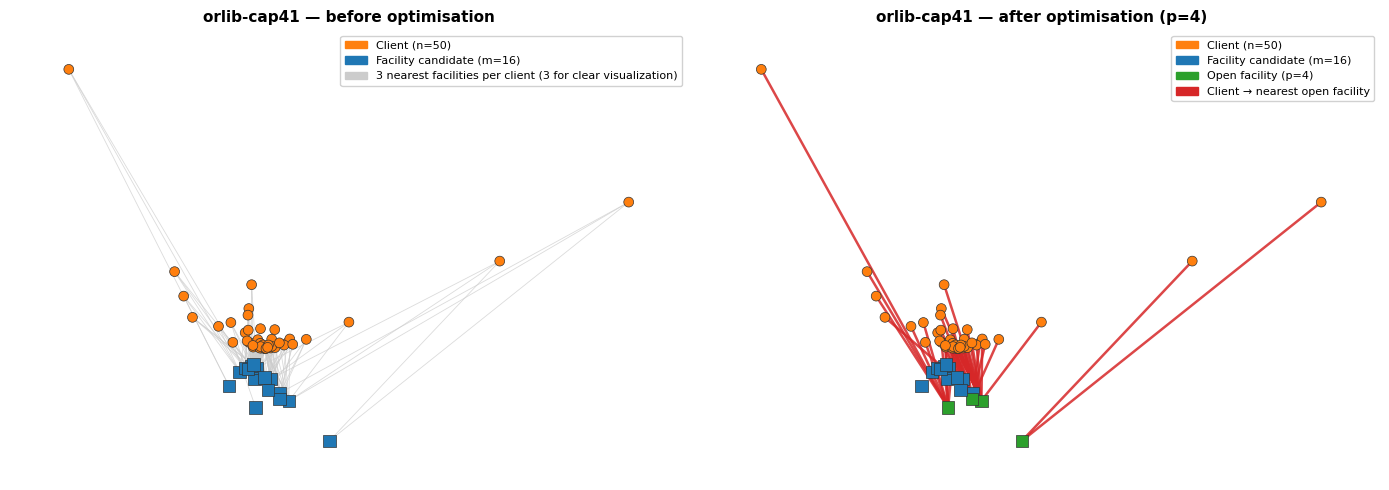


Instance : orlib-cap81  (n=50, m=25, p=6)


/home/mshaa1/Documenti/Decision-OPT-Assignment/.venv/lib/python3.14/site-packages/sklearn/manifold/_mds.py:735: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/home/mshaa1/Documenti/Decision-OPT-Assignment/.venv/lib/python3.14/site-packages/sklearn/manifold/_mds.py:752: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(
/home/mshaa1/Documenti/Decision-OPT-Assignment/.venv/lib/python3.14/site-packages/sklearn/manifold/_mds.py:760: FutureWarning: Use metric_mds=True instead of metric=True. The support for metric={True/False} will be dropped in 1.10.
  warnings.warn(


Gurobi Optimizer version 13.0.2 build v13.0.2rc1 (linux64 - "CachyOS")

CPU model: AMD Ryzen 7 9700X 8-Core Processor, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 8 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 1351 rows, 1426 columns and 5275 nonzeros (Max)
Model fingerprint: 0xebc0febd
Model has 51 linear objective coefficients
Variable types: 1401 continuous, 25 integer (25 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+06]
  Objective range  [1e+00, 5e+01]
  Bounds range     [1e+00, 1e+00]
  RHS range        [6e+00, 3e+06]

Found heuristic solution: objective -0.0000000
Presolve removed 50 rows and 1300 columns
Presolve time: 0.00s
Presolved: 1301 rows, 126 columns, 3875 nonzeros
Variable types: 101 continuous, 25 integer (25 binary)

Root relaxation: objective 5.444659e+07, 181 iterations, 0.00 seconds (0.01 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth

/home/mshaa1/Documenti/Decision-OPT-Assignment/.venv/lib/python3.14/site-packages/sklearn/manifold/_mds.py:735: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/home/mshaa1/Documenti/Decision-OPT-Assignment/.venv/lib/python3.14/site-packages/sklearn/manifold/_mds.py:752: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(
/home/mshaa1/Documenti/Decision-OPT-Assignment/.venv/lib/python3.14/site-packages/sklearn/manifold/_mds.py:760: FutureWarning: Use metric_mds=True instead of metric=True. The support for metric={True/False} will be dropped in 1.10.
  warnings.warn(


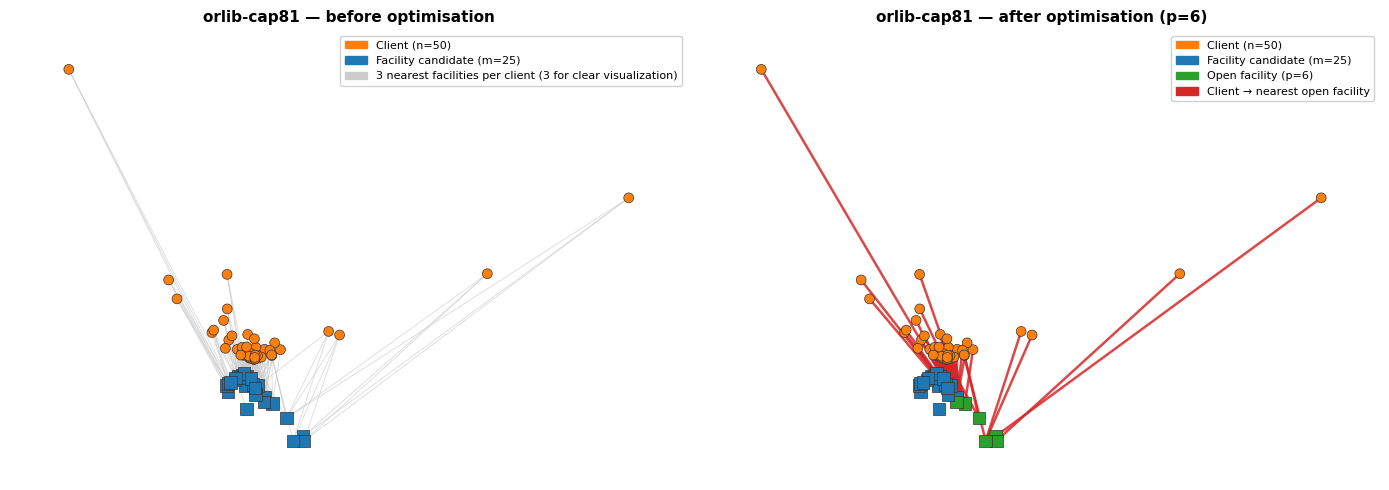


Instance : orlib-cap111  (n=50, m=50, p=12)
Gurobi Optimizer version 13.0.2 build v13.0.2rc1 (linux64 - "CachyOS")

CPU model: AMD Ryzen 7 9700X 8-Core Processor, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 8 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 2601 rows, 2701 columns and 10300 nonzeros (Max)
Model fingerprint: 0xd3386638
Model has 51 linear objective coefficients
Variable types: 2651 continuous, 50 integer (50 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+06]
  Objective range  [1e+00, 5e+01]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+01, 3e+06]

Found heuristic solution: objective -0.0000000
Presolve removed 50 rows and 2550 columns
Presolve time: 0.01s
Presolved: 2551 rows, 151 columns, 7650 nonzeros
Variable types: 101 continuous, 50 integer (50 binary)

Root relaxation: objective 5.441837e+07, 299 iterations, 0.01 seconds (0.02 work units)

    Nodes    |    Current Node    |     Objective Bou

/home/mshaa1/Documenti/Decision-OPT-Assignment/.venv/lib/python3.14/site-packages/sklearn/manifold/_mds.py:735: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/home/mshaa1/Documenti/Decision-OPT-Assignment/.venv/lib/python3.14/site-packages/sklearn/manifold/_mds.py:752: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(
/home/mshaa1/Documenti/Decision-OPT-Assignment/.venv/lib/python3.14/site-packages/sklearn/manifold/_mds.py:760: FutureWarning: Use metric_mds=True instead of metric=True. The support for metric={True/False} will be dropped in 1.10.
  warnings.warn(


     0     0 5.1377e+07    0   50 1117128.34 5.1377e+07  4499%     -    0s
H    0     0                    1300550.0375 5.1361e+07  3849%     -    0s
     0     0 4.9939e+07    0   50 1300550.04 4.9939e+07  3740%     -    0s
H    0     0                    1306872.1750 4.9934e+07  3721%     -    0s
     0     0 4.9910e+07    0   50 1306872.17 4.9910e+07  3719%     -    0s
     0     0 4.8655e+07    0   50 1306872.17 4.8655e+07  3623%     -    0s
H    0     0                    1578394.7375 4.8645e+07  2982%     -    0s
     0     0 4.7719e+07    0   50 1578394.74 4.7719e+07  2923%     -    0s
H    0     0                    1621135.2125 4.7657e+07  2840%     -    0s
     0     0 4.6807e+07    0   50 1621135.21 4.6807e+07  2787%     -    0s
H    0     0                    1622558.4500 4.6786e+07  2783%     -    0s
H    0     0                    1775967.9125 4.4811e+07  2423%     -    0s
     0     0 4.3750e+07    0   50 1775967.91 4.3750e+07  2363%     -    0s
     0     0 4.3115e+07  

/home/mshaa1/Documenti/Decision-OPT-Assignment/.venv/lib/python3.14/site-packages/sklearn/manifold/_mds.py:735: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/home/mshaa1/Documenti/Decision-OPT-Assignment/.venv/lib/python3.14/site-packages/sklearn/manifold/_mds.py:752: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(
/home/mshaa1/Documenti/Decision-OPT-Assignment/.venv/lib/python3.14/site-packages/sklearn/manifold/_mds.py:760: FutureWarning: Use metric_mds=True instead of metric=True. The support for metric={True/False} will be dropped in 1.10.
  warnings.warn(


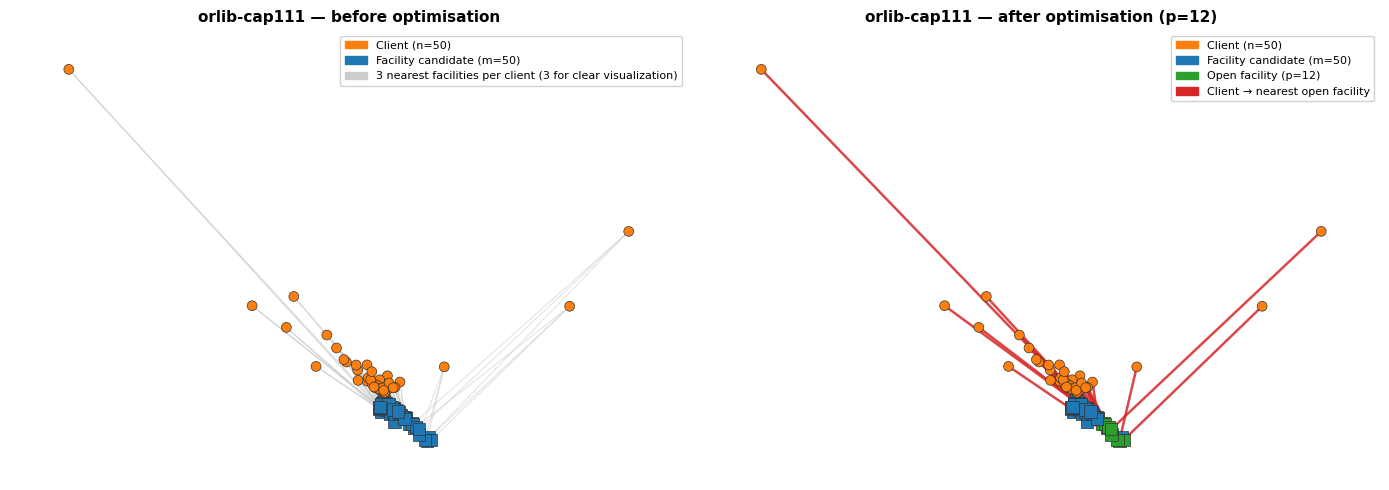

In [6]:
# Tiny test instances

for label, path in TINY_TEST_INSTANCES:
    inst = load_instance(path)
    n, m, p, d = inst["n"], inst["m"], inst["p"], inst["d"]
    print(f"\n{'='*60}")
    print(f"Instance : {label}  (n={n}, m={m}, p={p})")
    print(f"{'='*60}")

    # Graph before optimisation
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    plot_network(inst, title=f"{label} — before optimisation", ax=axes[0])

    sol = solve_unified_opmp(n, m, p, d)
    print(f"  Objective : {sol['obj']:.4f}")
    print(f"  Open      : {sorted(sol['open'])}")

    # Graph after optimisation
    plot_network(
        inst, title=f"{label} — after optimisation (p={p})",
        open_facilities=sol["open"], assignment=sol["assignment"], ax=axes[1]
    )
    plt.tight_layout()
    plt.show()


Instance : BK-D1.1  (n=80, m=30, p=7)
Gurobi Optimizer version 13.0.2 build v13.0.2rc1 (linux64 - "CachyOS")

CPU model: AMD Ryzen 7 9700X 8-Core Processor, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 8 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 2561 rows, 2671 columns and 10030 nonzeros (Max)
Model fingerprint: 0x35b17912
Model has 81 linear objective coefficients
Variable types: 2641 continuous, 30 integer (30 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+03]
  Objective range  [1e+00, 8e+01]
  Bounds range     [1e+00, 1e+00]
  RHS range        [7e+00, 2e+03]

Found heuristic solution: objective -0.0000000
Presolve removed 80 rows and 2480 columns
Presolve time: 0.01s
Presolved: 2481 rows, 191 columns, 7387 nonzeros
Variable types: 81 continuous, 110 integer (30 binary)

Root relaxation: objective 6.373900e+04, 271 iterations, 0.01 seconds (0.02 work units)

    Nodes    |    Current Node    |     Objective Bounds   

/home/mshaa1/Documenti/Decision-OPT-Assignment/.venv/lib/python3.14/site-packages/sklearn/manifold/_mds.py:735: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/home/mshaa1/Documenti/Decision-OPT-Assignment/.venv/lib/python3.14/site-packages/sklearn/manifold/_mds.py:752: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(
/home/mshaa1/Documenti/Decision-OPT-Assignment/.venv/lib/python3.14/site-packages/sklearn/manifold/_mds.py:760: FutureWarning: Use metric_mds=True instead of metric=True. The support for metric={True/False} will be dropped in 1.10.
  warnings.warn(


H    0     0                    10252.000000 63739.0000   522%     -    0s
H    0     0                    11282.000000 63739.0000   465%     -    0s
     0     0 55300.4189    0  110 11282.0000 55300.4189   390%     -    0s
     0     0 55260.8735    0  110 11282.0000 55260.8735   390%     -    0s
H    0     0                    11340.000000 55260.8735   387%     -    0s
     0     0 54584.6415    0  110 11340.0000 54584.6415   381%     -    0s
     0     0 54565.8835    0  110 11340.0000 54565.8835   381%     -    0s
     0     0 54565.8835    0  110 11340.0000 54565.8835   381%     -    0s
H    0     0                    12409.000000 54565.8835   340%     -    0s
     0     0 54289.9738    0  110 12409.0000 54289.9738   338%     -    0s
     0     0 54224.9184    0  110 12409.0000 54224.9184   337%     -    0s
     0     0 54213.1846    0  110 12409.0000 54213.1846   337%     -    0s
     0     0 54212.7509    0  110 12409.0000 54212.7509   337%     -    0s
     0     0 52097.8825  

/home/mshaa1/Documenti/Decision-OPT-Assignment/.venv/lib/python3.14/site-packages/sklearn/manifold/_mds.py:735: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/home/mshaa1/Documenti/Decision-OPT-Assignment/.venv/lib/python3.14/site-packages/sklearn/manifold/_mds.py:752: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(
/home/mshaa1/Documenti/Decision-OPT-Assignment/.venv/lib/python3.14/site-packages/sklearn/manifold/_mds.py:760: FutureWarning: Use metric_mds=True instead of metric=True. The support for metric={True/False} will be dropped in 1.10.
  warnings.warn(


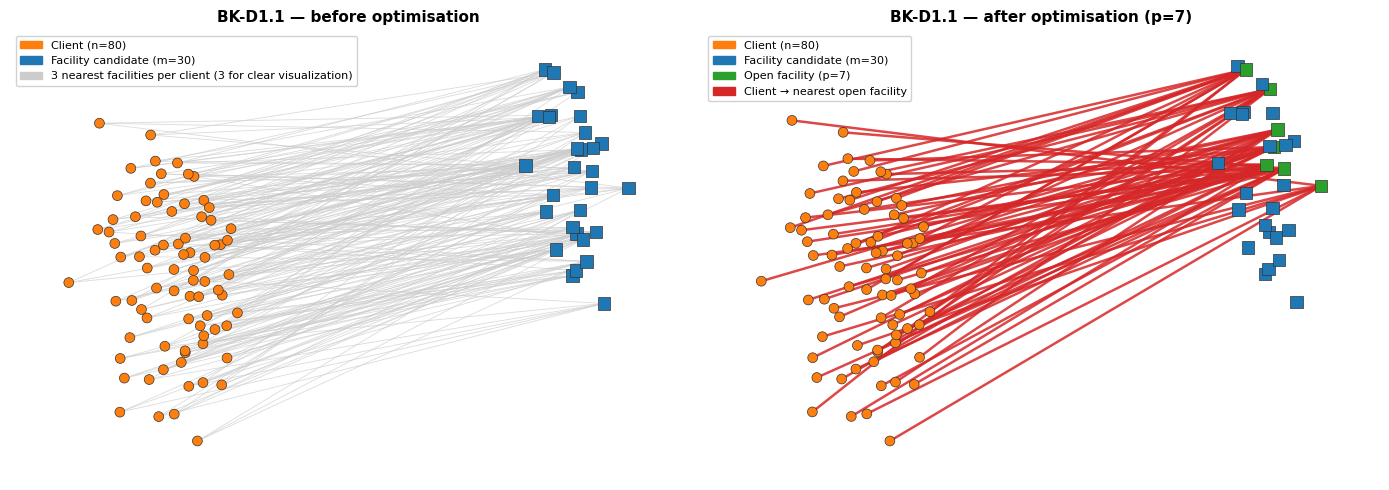


Instance : BK-D2.1  (n=80, m=30, p=7)
Gurobi Optimizer version 13.0.2 build v13.0.2rc1 (linux64 - "CachyOS")

CPU model: AMD Ryzen 7 9700X 8-Core Processor, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 8 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 2561 rows, 2671 columns and 10030 nonzeros (Max)
Model fingerprint: 0xab971133
Model has 81 linear objective coefficients
Variable types: 2641 continuous, 30 integer (30 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+03]
  Objective range  [1e+00, 8e+01]
  Bounds range     [1e+00, 1e+00]
  RHS range        [7e+00, 2e+03]

Found heuristic solution: objective -0.0000000
Presolve removed 80 rows and 2480 columns
Presolve time: 0.01s
Presolved: 2481 rows, 191 columns, 7390 nonzeros
Variable types: 81 continuous, 110 integer (30 binary)

Root relaxation: objective 6.381900e+04, 284 iterations, 0.01 seconds (0.03 work units)

    Nodes    |    Current Node    |     Objective Bounds   

/home/mshaa1/Documenti/Decision-OPT-Assignment/.venv/lib/python3.14/site-packages/sklearn/manifold/_mds.py:735: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/home/mshaa1/Documenti/Decision-OPT-Assignment/.venv/lib/python3.14/site-packages/sklearn/manifold/_mds.py:752: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(
/home/mshaa1/Documenti/Decision-OPT-Assignment/.venv/lib/python3.14/site-packages/sklearn/manifold/_mds.py:760: FutureWarning: Use metric_mds=True instead of metric=True. The support for metric={True/False} will be dropped in 1.10.
  warnings.warn(


H    0     0                    11107.000000 63819.0000   475%     -    0s
H    0     0                    11138.000000 63819.0000   473%     -    0s
H    0     0                    11404.000000 62434.1996   447%     -    0s
     0     0 56139.3717    0  110 11404.0000 56139.3717   392%     -    0s
H    0     0                    12955.000000 56058.2482   333%     -    0s
H    0     0                    13116.000000 56058.2482   327%     -    0s
     0     0 55312.7698    0  110 13116.0000 55312.7698   322%     -    0s
     0     0 55121.4049    0  110 13116.0000 55121.4049   320%     -    0s
H    0     0                    13266.000000 55094.3624   315%     -    0s
     0     0 55094.3624    0  110 13266.0000 55094.3624   315%     -    0s
     0     0 55094.3624    0  110 13266.0000 55094.3624   315%     -    0s
     0     0 55094.3624    0  110 13266.0000 55094.3624   315%     -    0s
     0     0 54893.9369    0  100 13266.0000 54893.9369   314%     -    0s
     0     0 54865.4245  

/home/mshaa1/Documenti/Decision-OPT-Assignment/.venv/lib/python3.14/site-packages/sklearn/manifold/_mds.py:735: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/home/mshaa1/Documenti/Decision-OPT-Assignment/.venv/lib/python3.14/site-packages/sklearn/manifold/_mds.py:752: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(
/home/mshaa1/Documenti/Decision-OPT-Assignment/.venv/lib/python3.14/site-packages/sklearn/manifold/_mds.py:760: FutureWarning: Use metric_mds=True instead of metric=True. The support for metric={True/False} will be dropped in 1.10.
  warnings.warn(


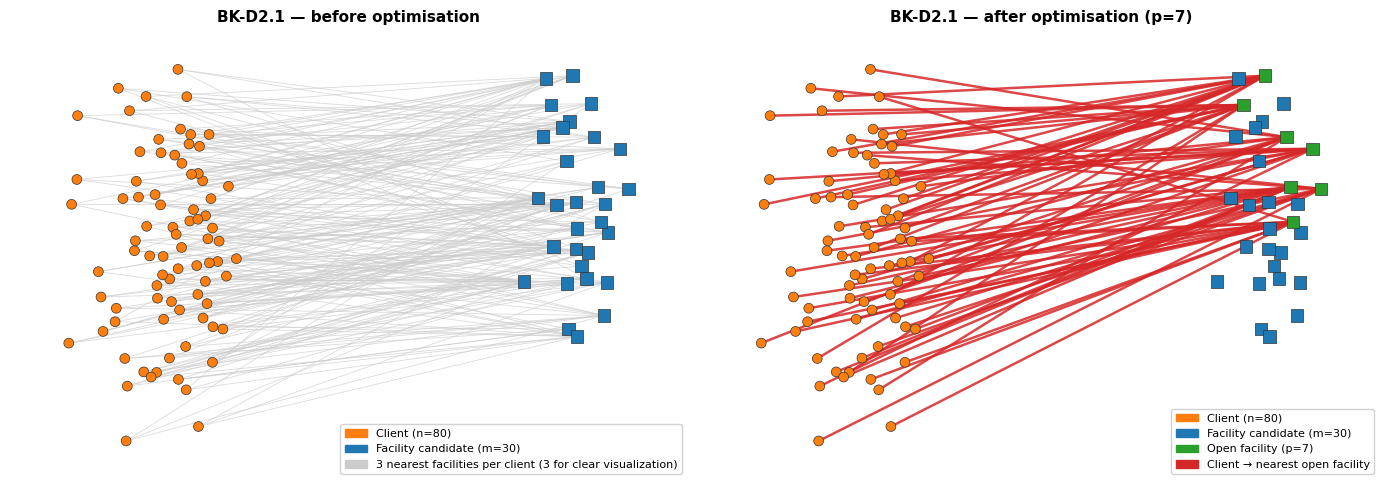

In [7]:
# Medium test instances

for label, path in MEDIUM_TEST_INSTANCES:
    inst = load_instance(path)
    n, m, p, d = inst["n"], inst["m"], inst["p"], inst["d"]
    print(f"\n{'='*60}")
    print(f"Instance : {label}  (n={n}, m={m}, p={p})")
    print(f"{'='*60}")

    # Graph before optimisation
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    plot_network(inst, title=f"{label} — before optimisation", ax=axes[0])

    sol = solve_unified_opmp(n, m, p, d)
    print(f"  Objective : {sol['obj']:.4f}")
    print(f"  Open      : {sorted(sol['open'])}")

    # Graph after optimisation
    plot_network(
        inst, title=f"{label} — after optimisation (p={p})",
        open_facilities=sol["open"], assignment=sol["assignment"], ax=axes[1]
    )
    plt.tight_layout()
    plt.show()


Instance : Hoefer-O1  (n=100, m=100, p=25)


/home/mshaa1/Documenti/Decision-OPT-Assignment/.venv/lib/python3.14/site-packages/sklearn/manifold/_mds.py:735: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/home/mshaa1/Documenti/Decision-OPT-Assignment/.venv/lib/python3.14/site-packages/sklearn/manifold/_mds.py:752: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(
/home/mshaa1/Documenti/Decision-OPT-Assignment/.venv/lib/python3.14/site-packages/sklearn/manifold/_mds.py:760: FutureWarning: Use metric_mds=True instead of metric=True. The support for metric={True/False} will be dropped in 1.10.
  warnings.warn(


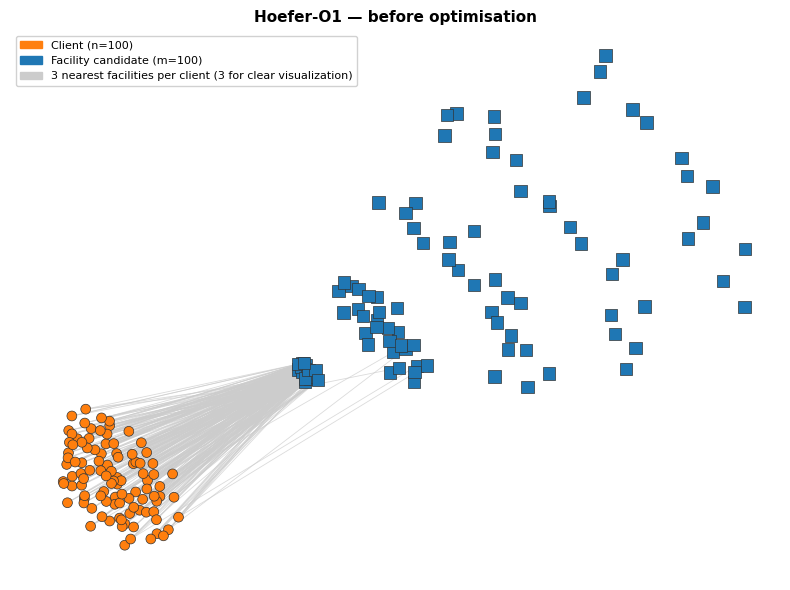

Gurobi Optimizer version 13.0.2 build v13.0.2rc1 (linux64 - "CachyOS")

CPU model: AMD Ryzen 7 9700X 8-Core Processor, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 8 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 10201 rows, 10401 columns and 40600 nonzeros (Max)
Model fingerprint: 0x2c2a0989
Model has 101 linear objective coefficients
Variable types: 10301 continuous, 100 integer (100 binary)
Coefficient statistics:
  Matrix range     [1e+00, 5e+01]
  Objective range  [1e+00, 1e+02]
  Bounds range     [1e+00, 1e+00]
  RHS range        [2e+01, 1e+02]

Found heuristic solution: objective -0.0000000
Presolve removed 100 rows and 10100 columns
Presolve time: 0.04s
Presolved: 10101 rows, 301 columns, 30300 nonzeros
Variable types: 201 continuous, 100 integer (100 binary)
Root relaxation presolved: 10101 rows, 301 columns, 30300 nonzeros


Root relaxation: objective 3.990153e+03, 641 iterations, 0.05 seconds (0.13 work units)

    Nodes    |    

/home/mshaa1/Documenti/Decision-OPT-Assignment/.venv/lib/python3.14/site-packages/sklearn/manifold/_mds.py:735: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/home/mshaa1/Documenti/Decision-OPT-Assignment/.venv/lib/python3.14/site-packages/sklearn/manifold/_mds.py:752: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(
/home/mshaa1/Documenti/Decision-OPT-Assignment/.venv/lib/python3.14/site-packages/sklearn/manifold/_mds.py:760: FutureWarning: Use metric_mds=True instead of metric=True. The support for metric={True/False} will be dropped in 1.10.
  warnings.warn(


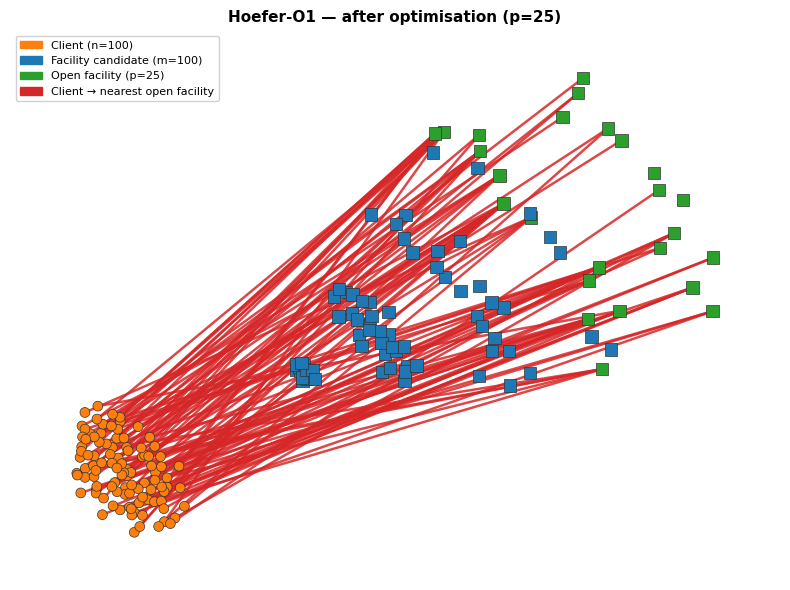

In [8]:
# Large test instance

label = LARGE_TEST_INSTANCE[0]
path = LARGE_TEST_INSTANCE[1]

inst = load_instance(path)
n, m, p, d = inst["n"], inst["m"], inst["p"], inst["d"]
print(f"\n{'='*60}")
print(f"Instance : {label}  (n={n}, m={m}, p={p})")
print(f"{'='*60}")

# Graph before optimisation — given the larger size, plotted on its own figure
plot_network(inst, title=f"{label} — before optimisation")

sol = solve_unified_opmp(n, m, p, d)
print(f"  Objective : {sol['obj']:.4f}")
print(f"  Open      : {sorted(sol['open'])}")

# Graph after optimisation
plot_network(
    inst, title=f"{label} — after optimisation (p={p})",
    open_facilities=sol["open"], assignment=sol["assignment"]
)

### Results

| Instance | n | m | p | Objective |
|---|---|---|---|---|
| orlib-cap41 | 50 | 16 | 4 | 2429355.4 |
| orlib-cap81 | 50 | 25 | 6 | 2539777.6375 |
| orlib-cap111 | 50 | 50 | 12 | 2802408.5875 |
| BK-D1.1 | 80 | 30 | 7 | 13832 |
| BK-D2.1 | 80 | 30 | 7 | 14461 |
| Hoefer-O1 | 100 | 100 | 25 | 102382.622 |